In [1]:
# Step 1: Data Preparation
import pandas as pd
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Display the first 5 rows
print("Step 1: Iris Dataset")
print(df.head())

Step 1: Iris Dataset
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


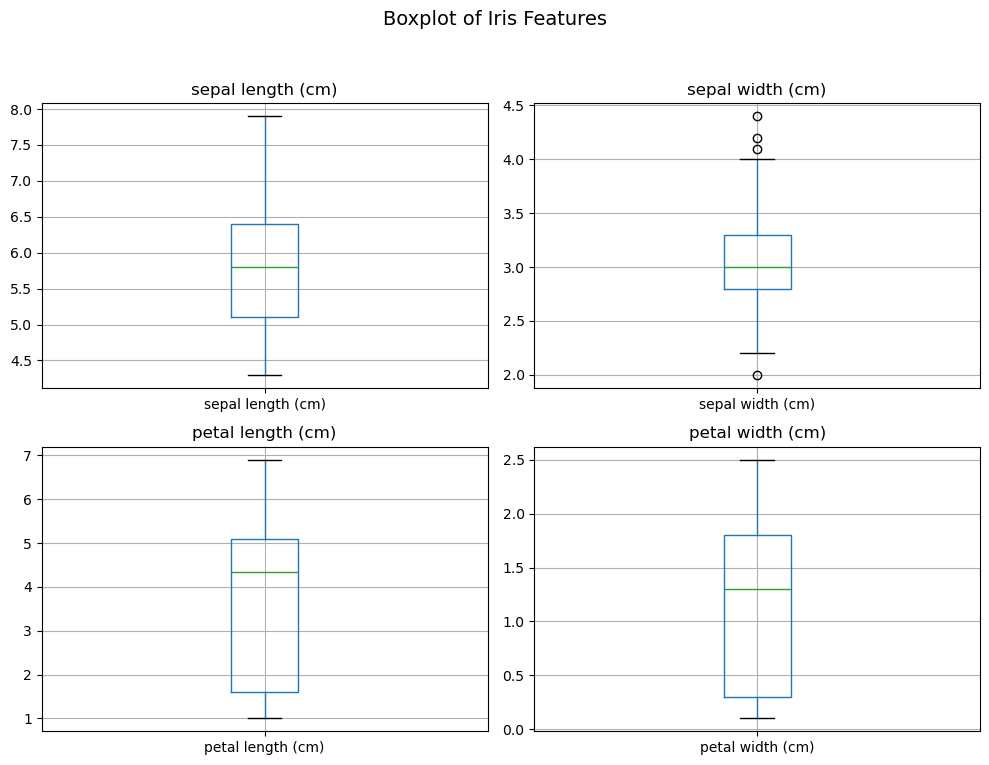

In [3]:
# Step 2: Data Cleaning
import matplotlib.pyplot as plt

# Only select numerical feature columns (exclude target 'species')
feature_columns = iris.feature_names
df_features = df[feature_columns]

# Create boxplots for all features
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
fig.suptitle('Boxplot of Iris Features', fontsize=14)

# Flatten axes for easy looping
axes = axes.flatten()

# Plot each feature
for i, col in enumerate(feature_columns):
    df_features.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Leave space for the suptitle
plt.savefig('boxplot.png')
plt.show()

In [5]:
# Step 3: Data Normalization
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Split data
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalize (optional for RF)
scaler = StandardScaler()

# Fit and transform the entire dataset (you could also scale just the training data)
X_scaled = scaler.fit_transform(X)

# Transform the training and testing sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display means and standard deviations before and after normalization
print("\nStep 3: Data Normalization")
print("Before normalization:")
print("Mean of each feature (X):", X.mean(axis=0))
print("Standard deviation of each feature (X):", X.std(axis=0))

print("\nAfter normalization:")
print("Mean of each feature (X_scaled):", X_scaled.mean(axis=0))
print("Standard deviation of each feature (X_scaled):", X_scaled.std(axis=0))

# Optionally, print a small part of the scaled data to verify
print("\nSample of scaled data:")
print(X_scaled[:5])  # Shows first 5 rows of the scaled data


Step 3: Data Normalization
Before normalization:
Mean of each feature (X): [5.84333333 3.05733333 3.758      1.19933333]
Standard deviation of each feature (X): [0.82530129 0.43441097 1.75940407 0.75969263]

After normalization:
Mean of each feature (X_scaled): [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Standard deviation of each feature (X_scaled): [1. 1. 1. 1.]

Sample of scaled data:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [7]:
# Step 4: Hyperparameter Tuning (Extra Step)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# GridSearchCV for optimal parameters
params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5]
}
grid = GridSearchCV(RandomForestClassifier(random_state=42), params, cv=5)
grid.fit(X_train, y_train)

print("\nStep 4: Best parameters found by GridSearchCV:")
print(grid.best_params_)


Step 4: Best parameters found by GridSearchCV:
{'max_depth': None, 'n_estimators': 100}



Step 5: Accuracy of Random Forest:
Accuracy: 1.0


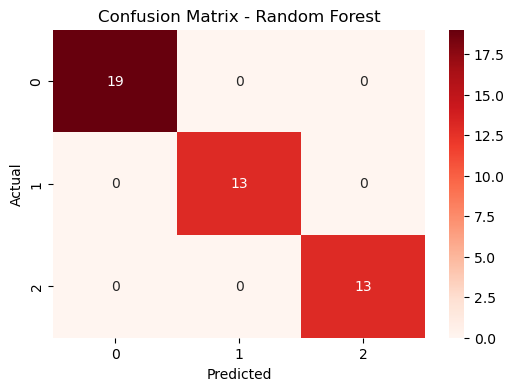

In [9]:
# Step 5: Model Training & Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# Train model
rf = RandomForestClassifier(**grid.best_params_, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Evaluate
print("\nStep 5: Accuracy of Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig('confusion_matrix.png')
plt.show()

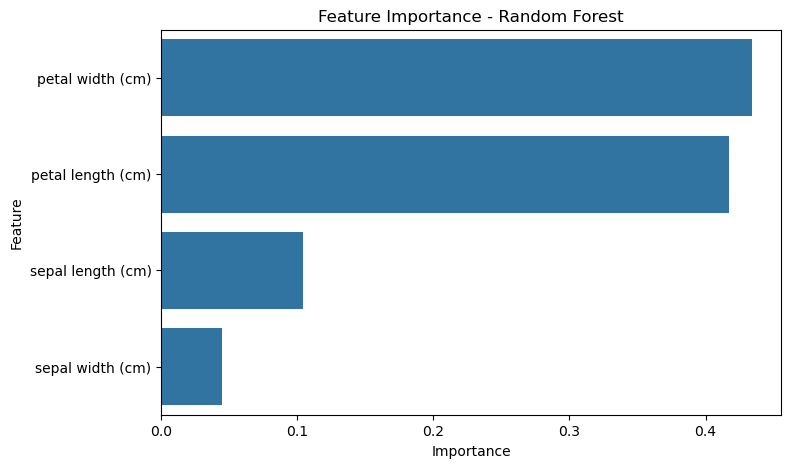

In [11]:
# Step 6: Feature Importance (Extra Step)
importance = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Feature Importance - Random Forest")
plt.savefig('feature_importance.png')
plt.show()

In [13]:
# Step 7: Cross-Validation (Extra Step)
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation
scores = cross_val_score(rf, X, y, cv=5)

print("\nStep 7: Cross-Validation Scores (Random Forest):")
print(scores)
print("Average CV Score:", scores.mean())


Step 7: Cross-Validation Scores (Random Forest):
[0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Average CV Score: 0.9666666666666668
